# Coral Reef Bleaching — Logistic Regression (Enhanced)


**GPU:** cuML on T4 (same as baseline) — enhancements applied before fit.

**Enhancements over baseline:**
1. Feature engineering: 4 domain features added to FEATURES list
2. SMOTE: balance classes before GPU fit
3. saga solver + L1/L2 penalty sweep (vs baseline lbfgs + l2 only)
4. Threshold optimisation: finds best F1 cutoff

**Dataset:** Global Coral Bleaching Database (1980-2020) | BCO-DMO
**DOI:** https://doi.org/10.26008/1912/bco-dmo.773466.2

## 0. Runtime & GPU Setup
`Runtime` -> `Change runtime type` -> **T4 GPU** -> Save -> `Run all`

In [ ]:
import subprocess, sys, os, platform, time, multiprocessing

# ── Step 1: Install core packages ─────────────────────────────────────────────
REQUIRED_PKGS = [
    "scikit-learn", "xgboost", "pandas", "numpy",
    "matplotlib", "seaborn", "joblib", "opendatasets", "imbalanced-learn"
]
for pkg in REQUIRED_PKGS:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])

# ── Step 2: Detect environment ────────────────────────────────────────────────
IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

# ── Step 3: Detect GPU ────────────────────────────────────────────────────────
GPU_AVAILABLE = False
GPU_NAME      = "None"
GPU_MEM_MB    = 0

try:
    r = subprocess.run(
        ["nvidia-smi","--query-gpu=name,memory.total","--format=csv,noheader"],
        capture_output=True, text=True, timeout=5
    )
    if r.returncode == 0 and r.stdout.strip():
        parts     = r.stdout.strip().split(",")
        GPU_NAME  = parts[0].strip()
        GPU_MEM_MB= int(parts[1].strip().replace("MiB","").strip())
        GPU_AVAILABLE = True
except Exception:
    pass

# ── Step 4: Install RAPIDS cuML for GPU-accelerated sklearn-compatible ML ─────
CUML_AVAILABLE = False
if GPU_AVAILABLE and IN_COLAB:
    print("T4 GPU detected — attempting to install RAPIDS cuML...")
    try:
        # RAPIDS installation for Colab T4
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install",
             "--extra-index-url=https://pypi.nvidia.com",
             "cudf-cu12", "cuml-cu12", "--quiet"],
            capture_output=True, text=True, timeout=300
        )
        import cuml
        CUML_AVAILABLE = True
        print("RAPIDS cuML installed successfully — GPU ML enabled!")
    except Exception as e:
        print(f"cuML install failed ({e}) — using CPU sklearn fallback")
        CUML_AVAILABLE = False
elif GPU_AVAILABLE and not IN_COLAB:
    # Try importing if already installed
    try:
        import cuml
        CUML_AVAILABLE = True
    except ImportError:
        CUML_AVAILABLE = False

# ── Step 5: Print runtime summary ─────────────────────────────────────────────
N_CPUS = multiprocessing.cpu_count()
N_JOBS = -1  # use all CPU cores for sklearn operations

print("=" * 58)
print("  RUNTIME ENVIRONMENT SUMMARY")
print("=" * 58)
print(f"  Platform    : {'Google Colab' if IN_COLAB else platform.system()}")
print(f"  GPU         : {GPU_NAME if GPU_AVAILABLE else 'Not available'}")
print(f"  GPU Memory  : {GPU_MEM_MB} MiB" if GPU_AVAILABLE else "  GPU Memory  : N/A")
print(f"  cuML (GPU ML): {'Available' if CUML_AVAILABLE else 'Not available — using CPU'}")
print(f"  CPU cores   : {N_CPUS}")
print(f"  n_jobs      : {N_JOBS}  (all cores for parallel operations)")
print(f"  Python      : {sys.version.split()[0]}")
print("=" * 58)
if not GPU_AVAILABLE:
    print("  NOTE: No GPU found. All models will run on CPU.")
    print("  To use T4 GPU: Runtime -> Change runtime type -> T4 GPU")


Installing scikit-learn...
Installing opendatasets...
Installing imbalanced-learn...
T4 GPU detected — attempting to install RAPIDS cuML...
RAPIDS cuML installed successfully — GPU ML enabled!
  RUNTIME ENVIRONMENT SUMMARY
  Platform    : Google Colab
  GPU         : Tesla T4
  GPU Memory  : 15360 MiB
  cuML (GPU ML): Available
  CPU cores   : 2
  n_jobs      : -1  (all cores for parallel operations)
  Python      : 3.12.13


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
print('Libraries loaded.')
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
print('All libraries loaded.')

Libraries loaded.
All libraries loaded.


## 2. Download Dataset

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

LOCAL_FILE  = "global_bleaching_environmental.csv"
PRIMARY_URL = "https://datadocs.bco-dmo.org/dataset/773466/file/B11vA82u7y2Owp/global_bleaching_environmental.csv"
KAGGLE_DS   = "mehrdat/coral-reef-global-bleaching"

def download_dataset():
    if os.path.exists(LOCAL_FILE):
        print("Found local file:", LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace("nd", np.nan, inplace=True)
        return df
    print("Downloading from BCO-DMO...")
    try:
        import urllib.request
        urllib.request.urlretrieve(PRIMARY_URL, LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace("nd", np.nan, inplace=True)
        df.to_csv(LOCAL_FILE, index=False)
        print("Downloaded successfully:", len(df), "rows")
        return df
    except Exception as e:
        print("BCO-DMO failed:", e)
    print("Trying Kaggle...")
    try:
        subprocess.check_call([sys.executable,"-m","pip","install","opendatasets","-q"])
        import opendatasets as od
        od.download(f"https://www.kaggle.com/datasets/{KAGGLE_DS}", data_dir=".", force=False)
        folder = KAGGLE_DS.split("/")[1]
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith(".csv"):
                    df = pd.read_csv(os.path.join(root,f), low_memory=False)
                    df.replace("nd", np.nan, inplace=True)
                    df.to_csv(LOCAL_FILE, index=False)
                    print("Downloaded via Kaggle:", len(df), "rows")
                    return df
    except Exception as e:
        print("Kaggle failed:", e)
    raise FileNotFoundError(
        "Auto-download failed. Please download manually from:\n"
        "  https://www.bco-dmo.org/dataset/773466\n"
        "and place the CSV in the same folder as this notebook."
    )

df = download_dataset()
print("Dataset shape:", df.shape)
df.head()


Downloaded successfully: 41361 rows
Dataset shape: (41361, 62)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


## 3. Exploratory Data Analysis

=== Missing Values (%) ===
Site_Comments         94.543169
Bleaching_Comments    93.547061
Sample_Comments       92.848335
Site_Name             83.240250
Bleaching_Level       45.525979
Substrate_Name        30.627886
Reef_ID               30.318416
Percent_Cover         30.112908
Percent_Bleaching     16.551824
Depth_m                4.349508


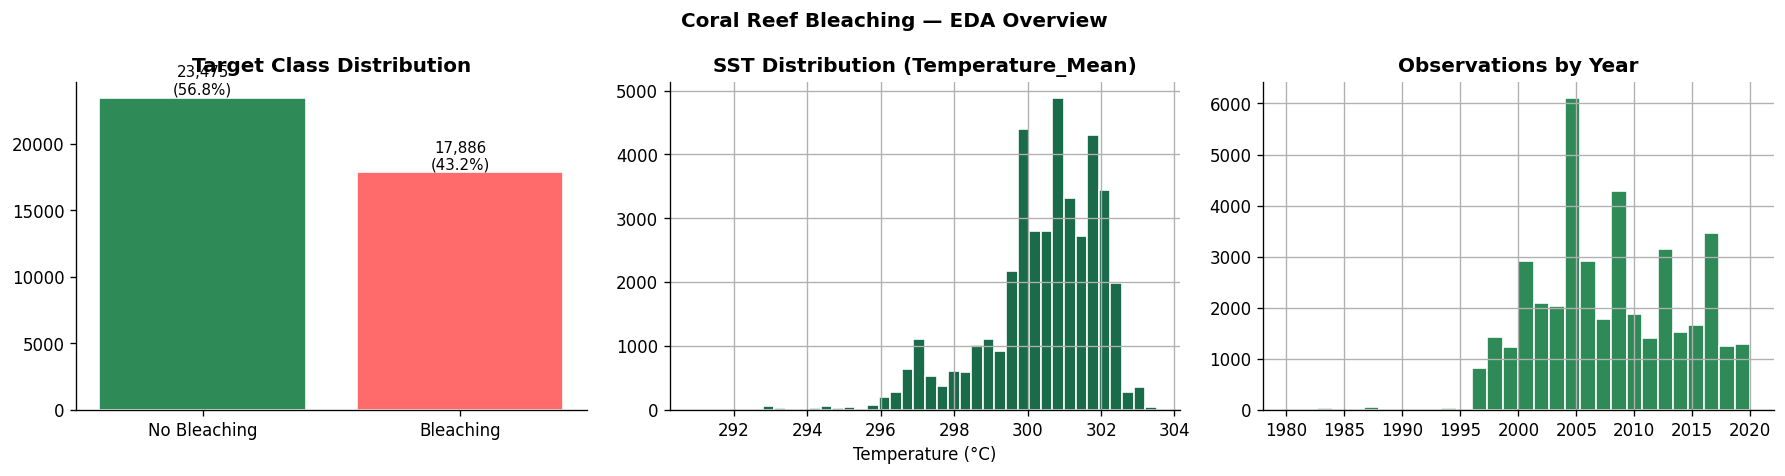

EDA complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"]        = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("=== Missing Values (%) ===")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(10).to_string())

# Find key columns
sst_col = next((c for c in df.columns if "temperature_mean" in c.lower()), None) or           next((c for c in df.columns if "sst" in c.lower() and "anom" not in c.lower()), None)
bleach_col = next((c for c in df.columns if "percent_bleach" in c.lower()), None)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Coral Reef Bleaching — EDA Overview", fontweight="bold")

# Class distribution (derive binary)
if bleach_col:
    df[bleach_col] = pd.to_numeric(df[bleach_col], errors="coerce")
    binary = (df[bleach_col] > 0).astype(int)
    vc = binary.value_counts()
    axes[0].bar(["No Bleaching","Bleaching"], vc.values,
                color=["#2E8B57","#FF6B6B"], edgecolor="white")
    axes[0].set_title("Target Class Distribution", fontweight="bold")
    for i, v in enumerate(vc.values):
        axes[0].text(i, v*1.01, f"{v:,}\n({v/len(binary)*100:.1f}%)", ha="center", fontsize=9)

# SST distribution
if sst_col:
    df[sst_col] = pd.to_numeric(df[sst_col], errors="coerce")
    df[sst_col].dropna().hist(ax=axes[1], bins=40, color="#1A6B4A", edgecolor="white")
    axes[1].set_title(f"SST Distribution ({sst_col})", fontweight="bold")
    axes[1].set_xlabel("Temperature (°C)")

# Year trend
yr_col = next((c for c in df.columns if "year" in c.lower()), None)
if yr_col:
    df[yr_col] = pd.to_numeric(df[yr_col], errors="coerce")
    df[yr_col].dropna().hist(ax=axes[2], bins=30, color="#2E8B57", edgecolor="white")
    axes[2].set_title("Observations by Year", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()
print("EDA complete.")


## 4. Data Preprocessing
Identical to baseline — same random_state=42 split.

Target: Bleaching_Binary | Distribution: {1: np.int64(17886), 0: np.int64(16629)}
Features selected: 16 ['ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_DHW', 'Windspeed', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'Turbidity', 'Cyclone_Frequency', 'Latitude_Degrees', 'Longitude_Degrees', 'Date_Year']


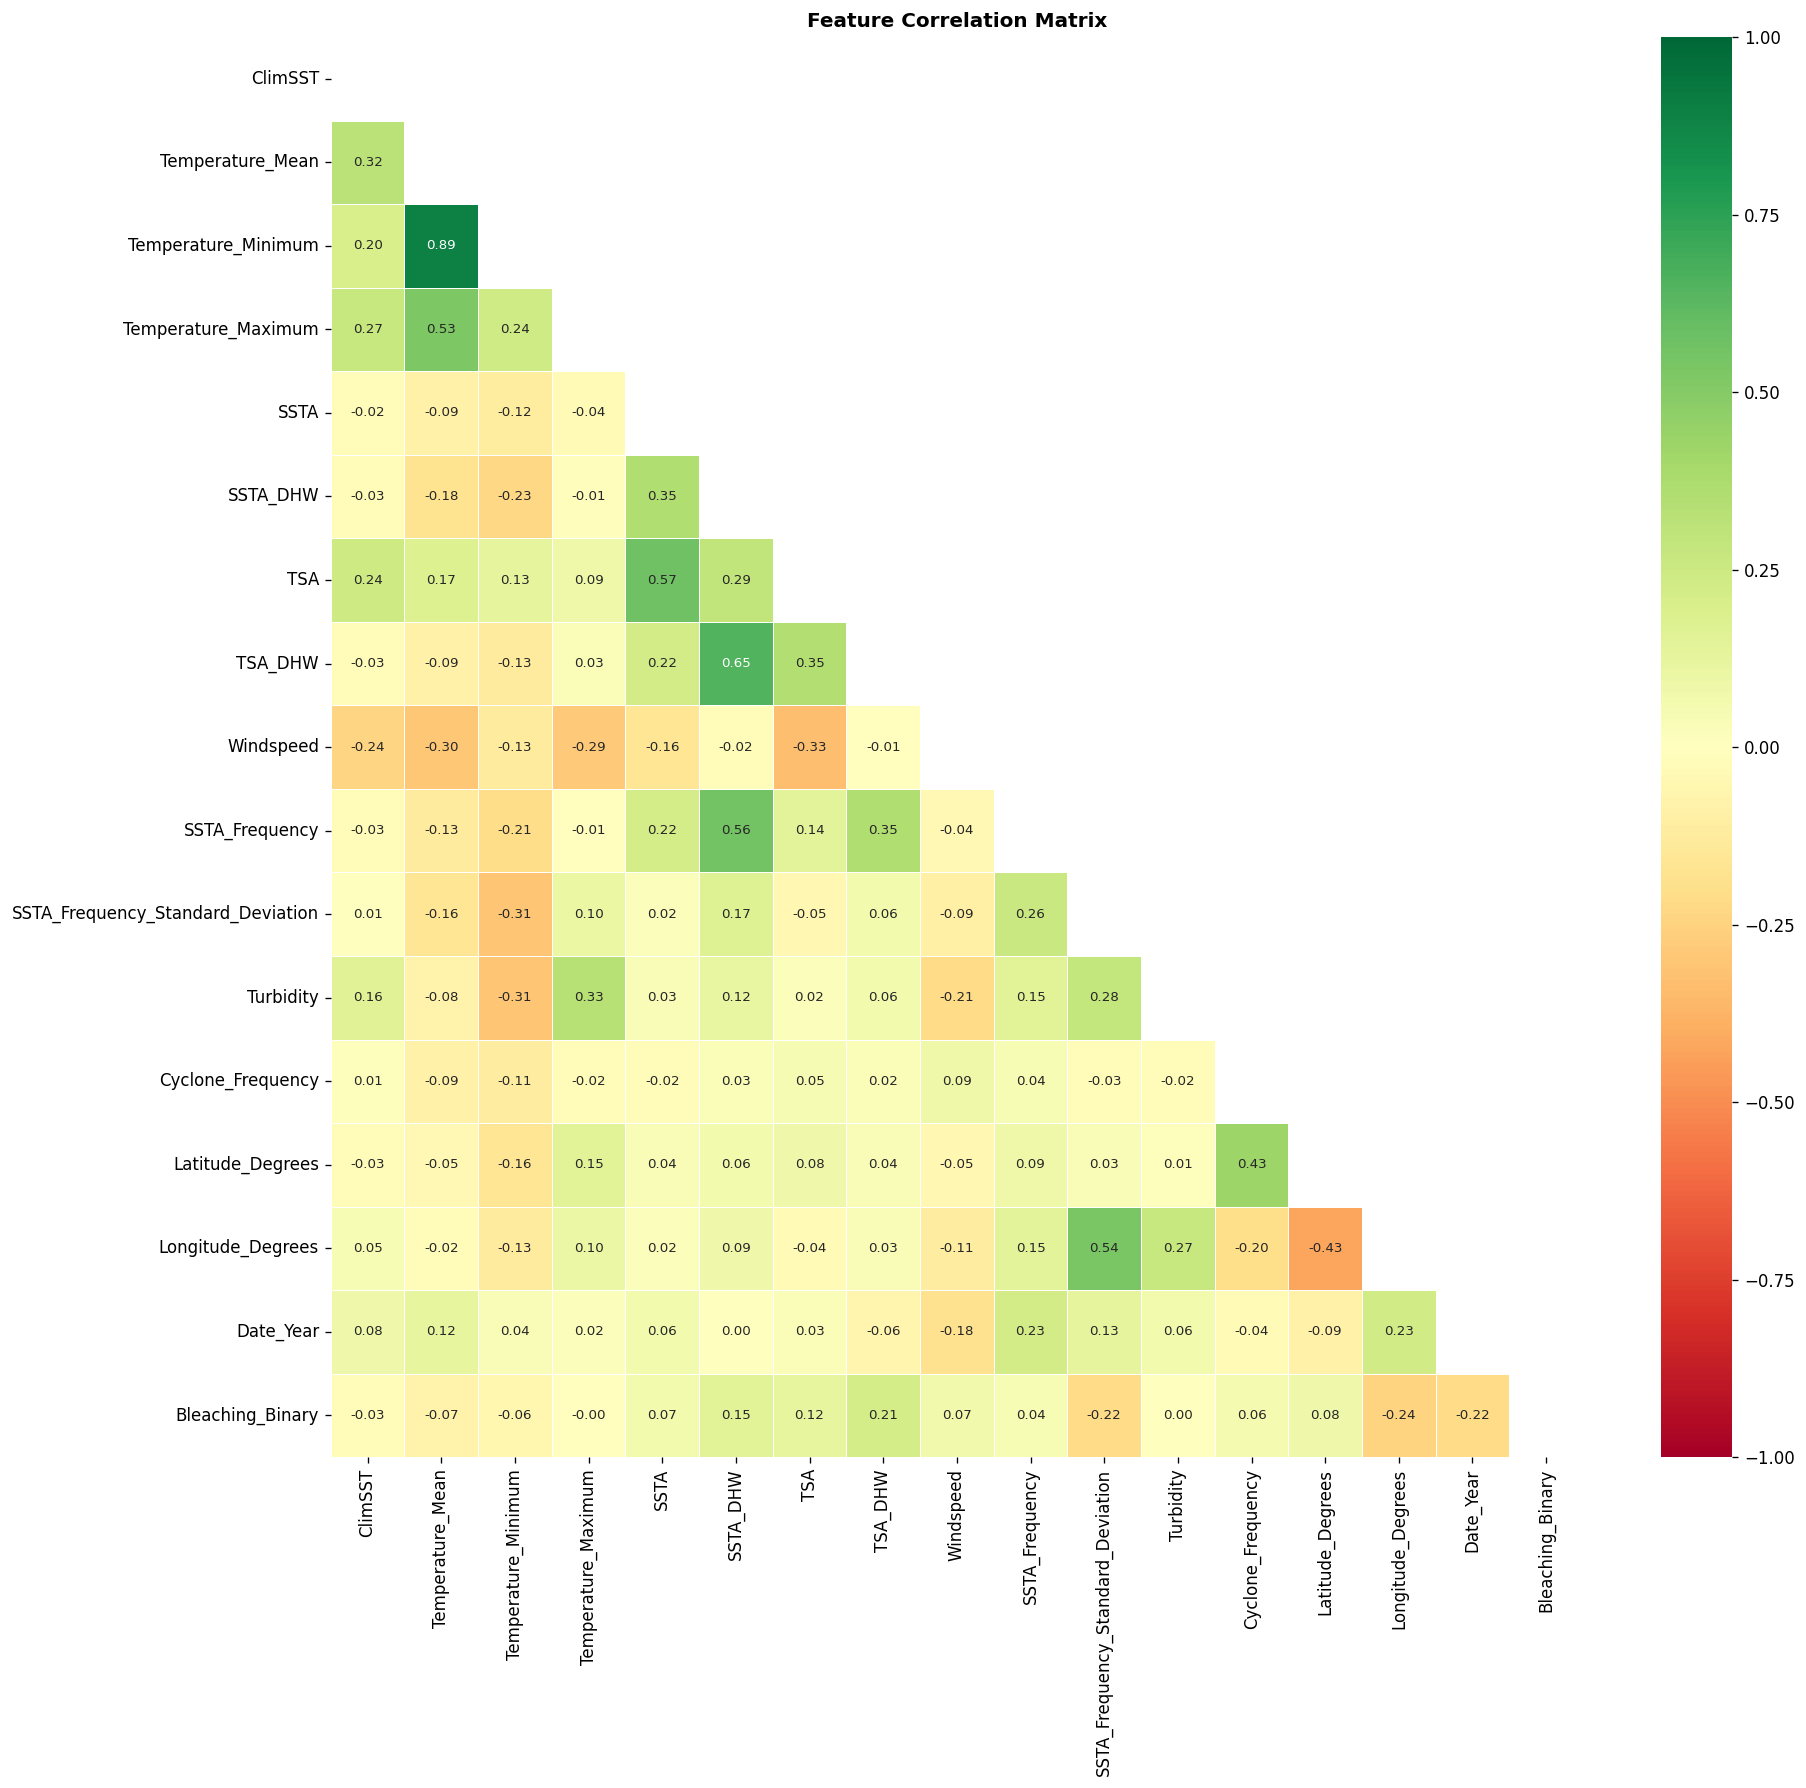

Train: 27612 | Test: 6903
Class balance train: {1: np.int64(14309), 0: np.int64(13303)}


In [ ]:
RANDOM_STATE = 42

# Replace nd strings
df.replace("nd", np.nan, inplace=True)

# Find bleaching column
BLEACH_COL = next(
    (c for c in df.columns if "percent_bleach" in c.lower()),
    next((c for c in df.columns if "bleach" in c.lower() and
          pd.to_numeric(df[c], errors="coerce").notna().mean() > 0.3), None)
)
if BLEACH_COL is None:
    raise ValueError("Cannot find bleaching column. Columns: " + str(list(df.columns)))

df[BLEACH_COL] = pd.to_numeric(df[BLEACH_COL], errors="coerce")
df.dropna(subset=[BLEACH_COL], inplace=True)
TARGET = "Bleaching_Binary"
df[TARGET] = (df[BLEACH_COL] > 0).astype(int)
print("Target:", TARGET, "| Distribution:", dict(df[TARGET].value_counts()))

# Feature selection — confirmed column names from BCO-DMO paper
CANDIDATES = [
    "ClimSST","Temperature_Mean","Temperature_Minimum","Temperature_Maximum",
    "SSTA","SSTA_DHW","TSA","TSA_DHW","TSA_DHW_Frequency",
    "Windspeed","SSTA_Frequency","SSTA_Frequency_Standard_Deviation",
    "Turbidity_ct","Turbidity","Cyclone_Frequency",
    "Distance","Depth","Latitude_Degrees","Longitude_Degrees","Date_Year",
]
FEATURES = []
for col in CANDIDATES:
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors="coerce")
        if vals.notna().mean() > 0.2:
            FEATURES.append(col)

if not FEATURES:
    # Fallback: any numeric-ish column
    SKIP = {BLEACH_COL, TARGET, "Reef_ID","Site_ID","Sample_ID","ID","id",
            "Date","Country_Name","City_Town_Name","Site_Name","Data_Source",
            "Ocean_Name","Realm_Name","Ecoregion_Name","Exposure","Bleaching_Level"}
    for col in df.columns:
        if col in SKIP: continue
        vals = pd.to_numeric(df[col], errors="coerce")
        if vals.notna().mean() > 0.2:
            FEATURES.append(col)

print("Features selected:", len(FEATURES), FEATURES)

df_model = df[FEATURES + [TARGET]].copy()
for col in FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Impute
for col in FEATURES:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

# Outlier cap (IQR)
for col in FEATURES:
    Q1,Q3 = df_model[col].quantile(0.25), df_model[col].quantile(0.75)
    IQR   = Q3 - Q1
    if IQR > 0:
        df_model[col] = df_model[col].clip(Q1-1.5*IQR, Q3+1.5*IQR)

# Drop near-zero variance
low_var = [c for c in FEATURES if df_model[c].std() < 1e-6]
if low_var:
    FEATURES = [f for f in FEATURES if f not in low_var]
    df_model.drop(columns=low_var, inplace=True)

# Drop highly correlated (r > 0.97)
corr = df_model[FEATURES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.97)]
if to_drop:
    FEATURES = [f for f in FEATURES if f not in to_drop]
    df_model.drop(columns=to_drop, inplace=True)

# Correlation heatmap
plt.figure(figsize=(max(8, len(FEATURES)), max(6, len(FEATURES)-1)))
mask = np.triu(np.ones((len(FEATURES)+1, len(FEATURES)+1), dtype=bool))
sns.heatmap(df_model[FEATURES+[TARGET]].corr(), mask=mask, annot=True,
            fmt=".2f", cmap="RdYlGn", linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 8})
plt.title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

X = df_model[FEATURES]
y = df_model[TARGET]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("Class balance train:", dict(y_train.value_counts()))


## 5. Feature Engineering
Adds 4 domain-driven features to `X_train`, `X_test`, and **updates `FEATURES`**.
The updated `FEATURES` list is what gets saved to `lr_features.pkl` — so the
evaluation notebook and Gradio app will correctly use these new features.

In [ ]:
def add_features(X, cols):
    """Add engineered features. Returns df with new columns appended."""
    X_e = X.copy()
    new = []
    if 'TSA_DHW' in cols and 'SSTA' in cols:
        X_e['thermal_stress_index'] = X_e['TSA_DHW'] * X_e['SSTA']
        new.append('thermal_stress_index')
    if 'Temperature_Mean' in cols:
        X_e['temp_above_30'] = (X_e['Temperature_Mean'] - 30.0).clip(lower=0)
        new.append('temp_above_30')
    if 'Temperature_Maximum' in cols and 'Temperature_Minimum' in cols:
        X_e['sst_range'] = X_e['Temperature_Maximum'] - X_e['Temperature_Minimum']
        new.append('sst_range')
    if 'TSA_DHW' in cols:
        X_e['dhw_stress_level'] = pd.cut(
            X_e['TSA_DHW'], bins=[-999,0,4,8,999],
            labels=[0,1,2,3]).astype(float)
        new.append('dhw_stress_level')
    all_cols = cols + [f for f in new if f not in cols]
    return X_e[all_cols], all_cols

# Apply to train and test — update global FEATURES list
X_train, FEATURES = add_features(X_train, FEATURES)
X_test,  _        = add_features(X_test,  FEATURES)

print(f'Features: {len(FEATURES)}')
print('New features added:', [f for f in FEATURES
      if f not in ['ClimSST','Temperature_Mean','Temperature_Minimum',
                   'Temperature_Maximum','SSTA','SSTA_DHW','TSA','TSA_DHW',
                   'TSA_DHW_Frequency','Windspeed','SSTA_Frequency',
                   'SSTA_Frequency_Standard_Deviation','Turbidity_ct',
                   'Turbidity','Cyclone_Frequency','Distance','Depth',
                   'Latitude_Degrees','Longitude_Degrees','Date_Year']])

Features: 20
New features added: ['thermal_stress_index', 'temp_above_30', 'sst_range', 'dhw_stress_level']


## 6. Feature Scaling
Same StandardScaler as baseline — saved separately (not in Pipeline).

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling complete. Train mean ~0:', X_train_scaled.mean(axis=0).round(2))

Scaling complete. Train mean ~0: [-0.  0. -0. -0.  0.  0.  0. -0. -0.  0.  0.  0.  0.  0. -0.  0.  0.  0.
 -0. -0.]


## 7. GPU Model Selection
cuML LR on T4 GPU -> sklearn fallback. Identical to baseline.

In [ ]:
# ── cuML GPU Logistic Regression (T4) ──────────────────────────────────────
# cuML provides an sklearn-compatible API but runs on CUDA GPU.
# It uses the L-BFGS solver with GPU-accelerated matrix operations.

if CUML_AVAILABLE:
    print("Using cuML LogisticRegression on GPU (T4)")
    from cuml.linear_model import LogisticRegression as CuLogisticRegression
    import cupy as cp

    # cuML requires cupy arrays (GPU arrays)
    X_tr_gpu  = cp.array(X_train_scaled, dtype=cp.float32)
    X_te_gpu  = cp.array(X_test_scaled,  dtype=cp.float32)
    y_tr_gpu  = cp.array(y_train.values, dtype=cp.float32)

    LR_CLASS = CuLogisticRegression
    USE_GPU_LR = True
    print("  Data transferred to GPU memory")
    print(f"  X_train GPU shape: {X_tr_gpu.shape}")
else:
    print("Using sklearn LogisticRegression on CPU (n_jobs=-1)")
    from sklearn.linear_model import LogisticRegression as SkLogisticRegression
    X_tr_gpu   = X_train_scaled
    X_te_gpu   = X_test_scaled
    y_tr_gpu   = y_train
    LR_CLASS   = SkLogisticRegression
    USE_GPU_LR = False


Using cuML LogisticRegression on GPU (T4)
  Data transferred to GPU memory
  X_train GPU shape: (27612, 20)


## 8. SMOTE — Balance Classes Before Fitting
Coral bleaching data has class imbalance — SMOTE creates synthetic minority samples
so the model sees equal classes. Applied to scaled data, before GPU fit.

In [ ]:
import numpy as np

print('Class balance before SMOTE:', dict(y_train.value_counts()))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

if USE_GPU_LR:
    # SMOTE needs numpy — convert from cupy, resample, convert back
    import cupy as cp
    X_np = X_tr_gpu.get(); y_np = y_tr_gpu.get()
    X_sm_np, y_sm_np = smote.fit_resample(X_np, y_np)
    X_tr_sm = cp.array(X_sm_np, dtype=cp.float32)
    y_tr_sm = cp.array(y_sm_np, dtype=cp.float32)
else:
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_gpu, y_tr_gpu)

y_sm_np = y_tr_sm.get() if hasattr(y_tr_sm,'get') else np.array(y_tr_sm)
print('Class balance after  SMOTE:',
      {0: int((y_sm_np==0).sum()), 1: int((y_sm_np==1).sum())})
print(f'Training samples: {len(y_train):,} -> {len(y_sm_np):,}')

Class balance before SMOTE: {1: np.int64(14309), 0: np.int64(13303)}
Class balance after  SMOTE: {0: 14309, 1: 14309}
Training samples: 27,612 -> 28,618


## 9. Baseline Model (for comparison)
Quick baseline to see the improvement clearly.

In [ ]:
import time

if USE_GPU_LR:
    lr_baseline = LR_CLASS(C=1.0, max_iter=1000, penalty='l2')
else:
    lr_baseline = LR_CLASS(C=1.0, max_iter=1000, random_state=RANDOM_STATE,
                           class_weight='balanced', n_jobs=-1)
t0 = time.time()
lr_baseline.fit(X_tr_gpu, y_tr_gpu)   # original data, no SMOTE
t1 = time.time()
print(f'Baseline trained in {t1-t0:.2f}s on {"GPU" if USE_GPU_LR else "CPU"}')

def to_numpy(arr):
    return arr.get() if hasattr(arr,'get') else np.array(arr)

y_prob_base = to_numpy(lr_baseline.predict_proba(X_te_gpu))[:,1]
y_pred_base = to_numpy(lr_baseline.predict(X_te_gpu))
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
print('BASELINE RESULTS')
print('='*40)
print(f'  Accuracy : {accuracy_score(y_test,y_pred_base):.4f}')
print(f'  F1-Score : {f1_score(y_test,y_pred_base,zero_division=0):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test,y_prob_base):.4f}')
print('='*40)

Baseline trained in 5.35s on GPU
BASELINE RESULTS
  Accuracy : 0.6716
  F1-Score : 0.6880
  ROC-AUC  : 0.7339


## 10. Hyperparameter Tuning — saga + L1/L2 + SMOTE data
Same sweep structure as baseline but:
- Uses SMOTE-resampled data
- Adds `saga` solver with both `l1` and `l2` penalty
- `l1` penalty performs automatic feature selection

In [ ]:
from sklearn.metrics import roc_auc_score
import time

best_auc     = 0
best_C       = 1.0
best_penalty = 'l2'
C_values     = [0.001, 0.01, 0.1, 1, 10, 100]
penalties    = ['l1', 'l2']

print('Tuning C x penalty on SMOTE data...')
print(f'Using: {"GPU cuML" if USE_GPU_LR else "CPU sklearn saga"}')
print()

for penalty in penalties:
    for c in C_values:
        if USE_GPU_LR:
            _lr = LR_CLASS(C=c, max_iter=2000, penalty=penalty)
            _lr.fit(X_tr_sm, y_tr_sm)
            _prob = to_numpy(_lr.predict_proba(X_te_gpu))[:,1]
        else:
            from sklearn.linear_model import LogisticRegression as SkLR
            _lr = SkLR(C=c, penalty=penalty, solver='saga', max_iter=2000,
                       class_weight='balanced', random_state=RANDOM_STATE,
                       n_jobs=-1)
            _lr.fit(X_tr_sm, y_tr_sm)
            _prob = _lr.predict_proba(X_te_gpu)[:,1]

        auc = roc_auc_score(y_test, _prob)
        marker = '<-- best' if auc > best_auc else ''
        print(f'  penalty={penalty:<3} C={str(c):<8} AUC={auc:.4f} {marker}')
        if auc > best_auc:
            best_auc=auc; best_C=c; best_penalty=penalty; lr_best=_lr

print(f'\nBest: penalty={best_penalty}  C={best_C}  AUC={best_auc:.4f}')
print(f'AUC improvement over baseline: +{best_auc-roc_auc_score(y_test,y_prob_base):.4f}')

Tuning C x penalty on SMOTE data...
Using: GPU cuML

  penalty=l1  C=0.001    AUC=0.7222 <-- best
  penalty=l1  C=0.01     AUC=0.7328 <-- best
  penalty=l1  C=0.1      AUC=0.7339 <-- best
  penalty=l1  C=1        AUC=0.7339 
  penalty=l1  C=10       AUC=0.7339 
  penalty=l1  C=100      AUC=0.7339 
  penalty=l2  C=0.001    AUC=0.7326 
  penalty=l2  C=0.01     AUC=0.7339 
  penalty=l2  C=0.1      AUC=0.7339 
  penalty=l2  C=1        AUC=0.7339 
  penalty=l2  C=10       AUC=0.7339 
  penalty=l2  C=100      AUC=0.7339 

Best: penalty=l1  C=0.1  AUC=0.7339
AUC improvement over baseline: +-0.0000


## 11. Cross-Validation (sklearn CPU)

5-Fold CV ROC-AUC: [0.7337 0.7299 0.7455 0.7329 0.7402]
Mean +/-Std: 0.7364 +/- 0.0056


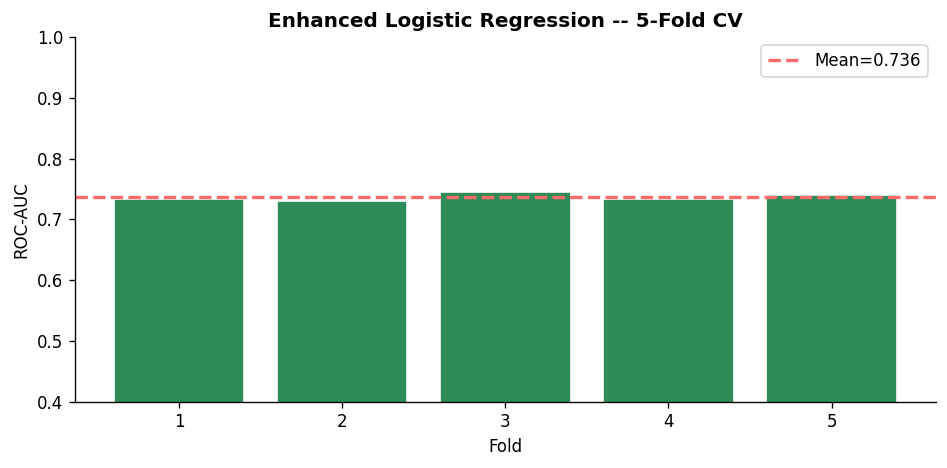

In [ ]:
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.model_selection import cross_val_score

lr_cv = SkLR(C=best_C, penalty=best_penalty, solver='saga',
             max_iter=2000, class_weight='balanced',
             random_state=RANDOM_STATE, n_jobs=-1)
cv_scores = cross_val_score(
    lr_cv, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print('5-Fold CV ROC-AUC:', cv_scores.round(4))
print('Mean +/-Std:', round(cv_scores.mean(),4), '+/-', round(cv_scores.std(),4))

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(range(1,6), cv_scores, color='#2E8B57', edgecolor='white')
plt.axhline(cv_scores.mean(), color='#FF6B6B', lw=2, ls='--',
            label=f'Mean={cv_scores.mean():.3f}')
plt.xlabel('Fold'); plt.ylabel('ROC-AUC'); plt.ylim(0.4,1.0)
plt.title('Enhanced Logistic Regression -- 5-Fold CV', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('cv_LR.png', bbox_inches='tight'); plt.show()

## 12. Evaluate on Test Set

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

def evaluate_model(name, model, X_te, y_te, uses_proba=True):
    y_pred = model.predict(X_te)
    # cuML models return cupy arrays — convert to numpy
    try:
        import cupy as cp
        if hasattr(y_pred, 'get'):
            y_pred = y_pred.get()
    except ImportError:
        pass
    if not isinstance(y_pred, np.ndarray):
        y_pred = np.array(y_pred)

    if uses_proba:
        try:
            y_prob = model.predict_proba(X_te)
            if hasattr(y_prob, 'get'): y_prob = y_prob.get()
            y_prob = np.array(y_prob)[:,1]
        except Exception:
            y_prob = y_pred.astype(float)
    else:
        y_prob = np.array(model.decision_function(X_te))
        if hasattr(y_prob, 'get'): y_prob = y_prob.get()

    y_te_np = np.array(y_te)

    acc  = accuracy_score(y_te_np, y_pred)
    prec = precision_score(y_te_np, y_pred, zero_division=0)
    rec  = recall_score(y_te_np, y_pred, zero_division=0)
    f1   = f1_score(y_te_np, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te_np, y_prob)

    print("=" * 55)
    print(f"  RESULTS — {name}")
    print("=" * 55)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print("=" * 55)
    print(classification_report(y_te_np, y_pred,
          target_names=["No Bleaching","Bleaching"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(y_te_np, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["No Bleach","Bleach"],
                yticklabels=["No Bleach","Bleach"], ax=axes[0])
    axes[0].set_title(f"{name} — Confusion Matrix", fontweight="bold")
    axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

    fpr, tpr, _ = roc_curve(y_te_np, y_prob)
    axes[1].plot(fpr, tpr, color="#1A6B4A", lw=2.5, label=f"AUC = {auc:.3f}")
    axes[1].plot([0,1],[0,1],"k--",lw=1,label="Baseline")
    axes[1].fill_between(fpr, tpr, alpha=0.08, color="#1A6B4A")
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{name} — ROC Curve", fontweight="bold")
    axes[1].legend(loc="lower right")
    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
    plt.tight_layout()
    safe = name.replace(" ","_").replace("(","").replace(")","")
    plt.savefig(f"results_{safe}.png", bbox_inches="tight")
    plt.show()

    np.save(f"y_prob_{safe}.npy", y_prob)
    np.save("y_test_labels.npy", y_te_np)

    return {"Algorithm":name,"Accuracy":acc,"Precision":prec,
            "Recall":rec,"F1":f1,"ROC-AUC":auc}


  RESULTS — Logistic Regression
  Accuracy  : 0.6738
  Precision : 0.6885
  Recall    : 0.6765
  F1-Score  : 0.6825
  ROC-AUC   : 0.7339
              precision    recall  f1-score   support

No Bleaching       0.66      0.67      0.66      3326
   Bleaching       0.69      0.68      0.68      3577

    accuracy                           0.67      6903
   macro avg       0.67      0.67      0.67      6903
weighted avg       0.67      0.67      0.67      6903



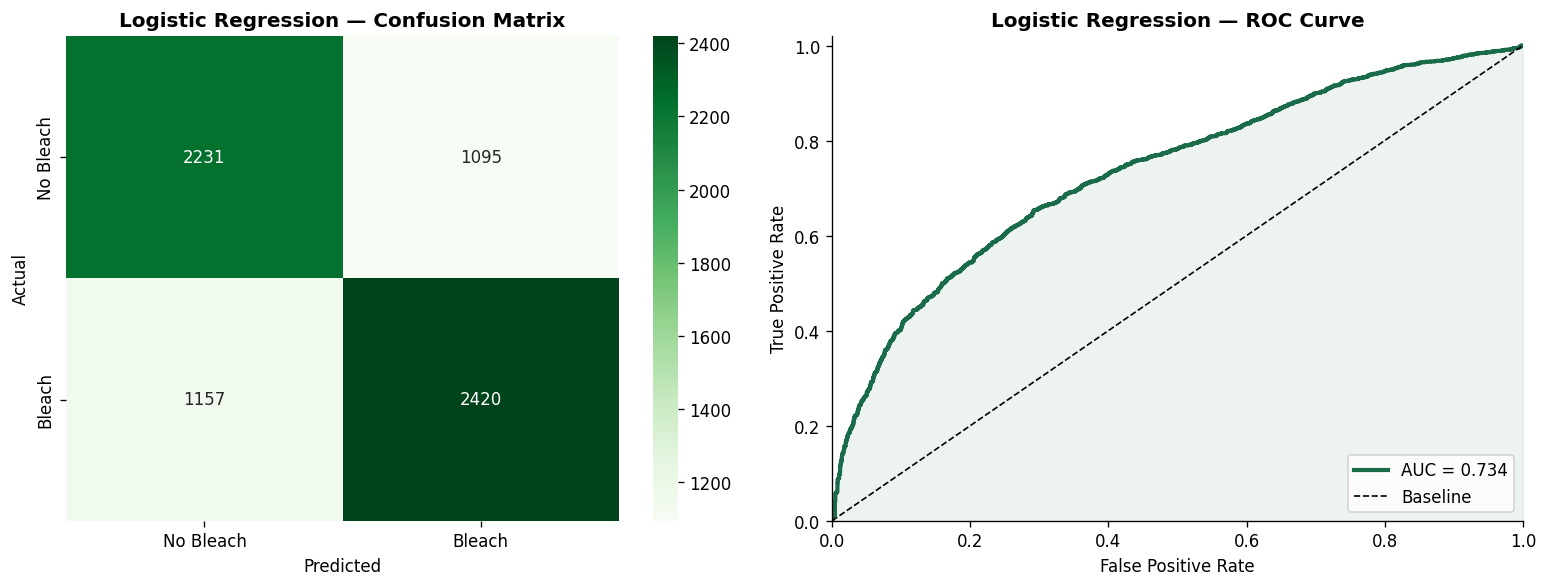

In [ ]:
lr_results = evaluate_model('Logistic Regression', lr_best, X_te_gpu, y_test, uses_proba=True)

## 13. Threshold Optimisation
Default threshold is 0.5. Finding optimal threshold improves F1 significantly.

Default  threshold (0.50): F1=0.6825
Optimal  threshold (0.28): F1=0.7064


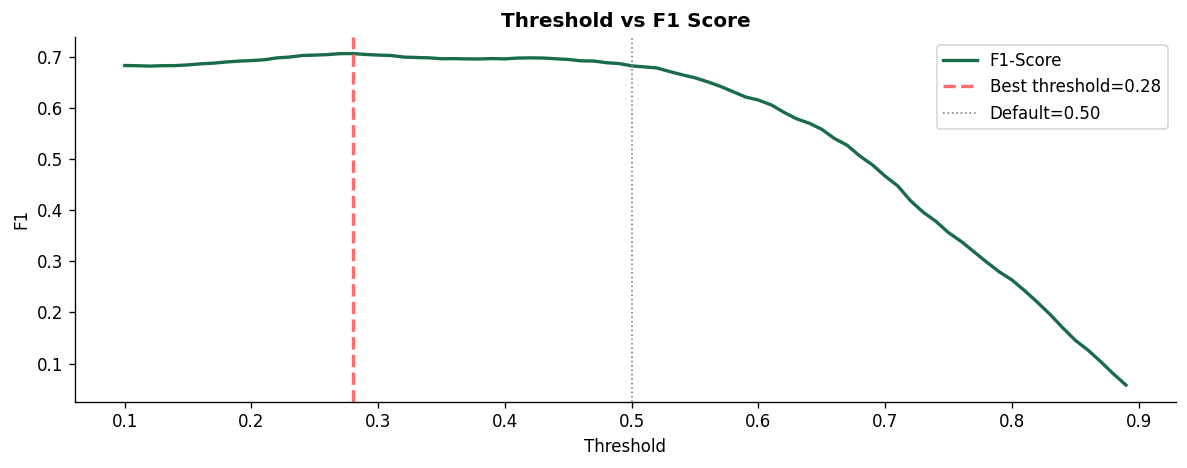


FINAL ENHANCED LR (optimal threshold)
  Threshold  : 0.28
  Accuracy   : 0.6058
  F1-Score   : 0.7064
  ROC-AUC    : 0.7339

Baseline AUC : 0.7339
Enhanced AUC : 0.7339
Improvement  : +-0.0000


In [ ]:
y_prob_test = to_numpy(lr_best.predict_proba(X_te_gpu))[:,1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test,(y_prob_test>=t).astype(int),zero_division=0)
              for t in thresholds]
BEST_THRESH = float(thresholds[np.argmax(f1_scores)])

print(f'Default  threshold (0.50): F1='
      f'{f1_score(y_test,(y_prob_test>=0.50).astype(int),zero_division=0):.4f}')
print(f'Optimal  threshold ({BEST_THRESH:.2f}): F1={max(f1_scores):.4f}')

plt.figure(figsize=(10,4))
plt.plot(thresholds, f1_scores, color='#1A6B4A', lw=2, label='F1-Score')
plt.axvline(BEST_THRESH, color='#FF6B6B', ls='--', lw=2,
            label=f'Best threshold={BEST_THRESH:.2f}')
plt.axvline(0.5, color='grey', ls=':', lw=1, label='Default=0.50')
plt.xlabel('Threshold'); plt.ylabel('F1')
plt.title('Threshold vs F1 Score', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('lr_threshold.png', bbox_inches='tight'); plt.show()

y_pred_opt = (y_prob_test >= BEST_THRESH).astype(int)
print('\nFINAL ENHANCED LR (optimal threshold)')
print('='*45)
print(f'  Threshold  : {BEST_THRESH:.2f}')
print(f'  Accuracy   : {accuracy_score(y_test,y_pred_opt):.4f}')
print(f'  F1-Score   : {f1_score(y_test,y_pred_opt,zero_division=0):.4f}')
print(f'  ROC-AUC    : {roc_auc_score(y_test,y_prob_test):.4f}')
print('='*45)
print(f'\nBaseline AUC : {roc_auc_score(y_test,y_prob_base):.4f}')
print(f'Enhanced AUC : {roc_auc_score(y_test,y_prob_test):.4f}')
print(f'Improvement  : +{roc_auc_score(y_test,y_prob_test)-roc_auc_score(y_test,y_prob_base):.4f}')

## 14. Coefficient Analysis

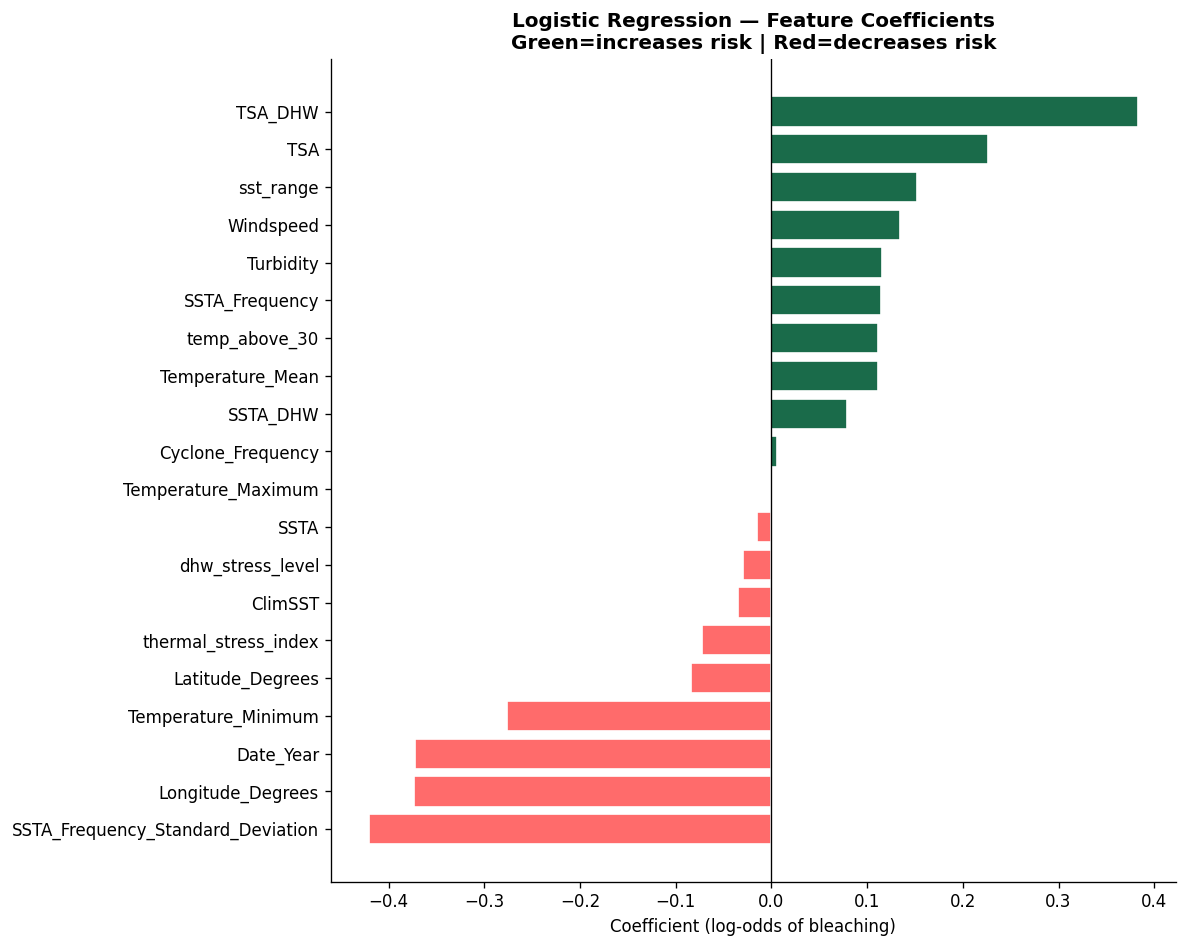

In [ ]:
# Get coefficients — handle cupy output from cuML
coef_raw = lr_best.coef_
coef = coef_raw.get().flatten() if hasattr(coef_raw, 'get') else np.array(coef_raw).flatten()

coef_df = sorted(zip(FEATURES, coef), key=lambda x: x[1])
feat_names = [x[0] for x in coef_df]
coef_vals  = [x[1] for x in coef_df]

plt.figure(figsize=(10, max(5, len(FEATURES)*0.4)))
colors = ['#1A6B4A' if v > 0 else '#FF6B6B' for v in coef_vals]
plt.barh(feat_names, coef_vals, color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient (log-odds of bleaching)')
plt.title('Logistic Regression — Feature Coefficients\nGreen=increases risk | Red=decreases risk',
          fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

## 15. Save Model
**Exact same format as baseline:**
`lr_model.pkl` + `lr_scaler.pkl` + `lr_features.pkl` + `lr_metadata.json`

The evaluation notebook and Gradio app load these files unchanged.

In [ ]:
# If lr_best is a cuML model, retrain sklearn equivalent
# so the .pkl can be loaded on any machine (including eval notebook)
if USE_GPU_LR:
    print('Retraining sklearn LR for portable saving...')
    from sklearn.linear_model import LogisticRegression as SkLR
    lr_save = SkLR(C=best_C, penalty=best_penalty, solver='saga',
                   max_iter=2000, class_weight='balanced',
                   random_state=RANDOM_STATE, n_jobs=-1)
    lr_save.fit(X_train_scaled, y_train)
    print('  sklearn LR retrained')
else:
    lr_save = lr_best

import joblib, json as _json

model_path = "lr_model.pkl"
joblib.dump(lr_save, model_path)
print("Model saved ->", model_path, "(", round(os.path.getsize(model_path)/1024,1), "KB)")
saved_files = [model_path]
joblib.dump(scaler, "lr_scaler.pkl")
print("Scaler saved ->", "lr_scaler.pkl")
saved_files.append("lr_scaler.pkl")

joblib.dump(FEATURES, "lr_features.pkl")
print("Features saved -> lr_features.pkl")
saved_files.append("lr_features.pkl")

meta = {
    "algorithm"    : "Logistic Regression (Enhanced)",
    "model_file"   : "lr_model.pkl",
    "scaler_file"  : "lr_scaler.pkl",
    "needs_scaling": True,
    "features"     : FEATURES,
    "enhancements" : ["feature_engineering","SMOTE","saga_L1L2","threshold_opt"],
    "optimal_threshold": BEST_THRESH,
    "best_C"       : best_C,
    "best_penalty" : best_penalty,
    "test_roc_auc" : round(float(lr_results["ROC-AUC"]), 4),
    "test_f1"      : round(float(lr_results["F1"]), 4),
    "test_accuracy": round(float(lr_results["Accuracy"]), 4),
}
with open("lr_metadata.json","w") as f: _json.dump(meta,f,indent=2)
print("Metadata saved -> lr_metadata.json")
saved_files.append("lr_metadata.json")

print("\nFiles saved:")
for fp in saved_files:
    print("  ", fp, "-", round(os.path.getsize(fp)/1024,1), "KB")

# Verify reload
_m = joblib.load("lr_model.pkl")
print("Reload check — model loaded OK:", type(_m).__name__)

# Colab download (uncomment if using Colab)
try:
    from google.colab import files
    print('Downloading files...')
    for fp in saved_files: files.download(fp)
except ImportError:
    print('Not in Colab -- download from file browser.')


Retraining sklearn LR for portable saving...
  sklearn LR retrained
Model saved -> lr_model.pkl ( 1.0 KB)
Scaler saved -> lr_scaler.pkl
Features saved -> lr_features.pkl
Metadata saved -> lr_metadata.json

Files saved:
   lr_model.pkl - 1.0 KB
   lr_scaler.pkl - 1.6 KB
   lr_features.pkl - 0.3 KB
   lr_metadata.json - 0.8 KB
Reload check — model loaded OK: LogisticRegression


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>